# Market Signal Analysis

This notebook performs a simple market time-series analysis using synthetic sample price data.

The goal is to demonstrate basic data loading, timestamp cleaning, feature engineering, and visual inspection of price and volatility.


In [36]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import sys

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from metrics import (
    calculate_returns,
    calculate_max_drawdown,
    calculate_win_rate,
    calculate_sharpe_like,
)
from signals import momentum_signal

dataset_file = "sample_prices.csv"
data_path = project_root / "data" / dataset_file

print(f"Using dataset: {dataset_file}")

df = pd.read_csv(data_path)

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp")
df = df.set_index("timestamp")

df.head()

df.info()


Using dataset: sample_prices.csv
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 720 entries, 2024-01-01 00:00:00 to 2024-01-30 23:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   720 non-null    float64
dtypes: float64(1)
memory usage: 11.2 KB


## Feature engineering


In [37]:
rolling_window = 24

df["return"] = calculate_returns(df["close"])
df["rolling_mean"] = df["close"].rolling(window=rolling_window).mean()
df["rolling_volatility"] = df["return"].rolling(window=rolling_window).std()

df.head(30)

,close,return,rolling_mean,rolling_volatility
timestamp,,,,
2024-01-01 00:00:00,42143.96,NaN,NaN,NaN
2024-01-01 01:00:00,42139.79,-0.000099,NaN,NaN
2024-01-01 02:00:00,42195.24,0.001316,NaN,NaN
2024-01-01 03:00:00,42317.24,0.002891,NaN,NaN
2024-01-01 04:00:00,42305.76,-0.000271,NaN,NaN
2024-01-01 05:00:00,42294.27,-0.000272,NaN,NaN
2024-01-01 06:00:00,42420.84,0.002993,NaN,NaN
2024-01-01 07:00:00,42485.80,0.001531,NaN,NaN
2024-01-01 08:00:00,42456.27,-0.000695,NaN,NaN


## Price chart


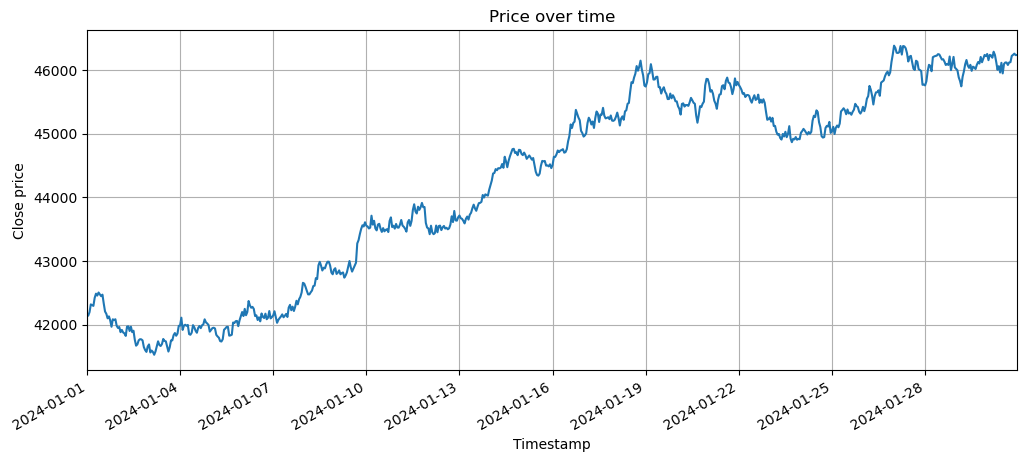

In [38]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["close"], linewidth=1.5)

ax.set_title("Price over time")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Close price")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

ax.set_xlim(df.index.min(), df.index.max())

fig.autofmt_xdate()
plt.show()


## Rolling volatility chart

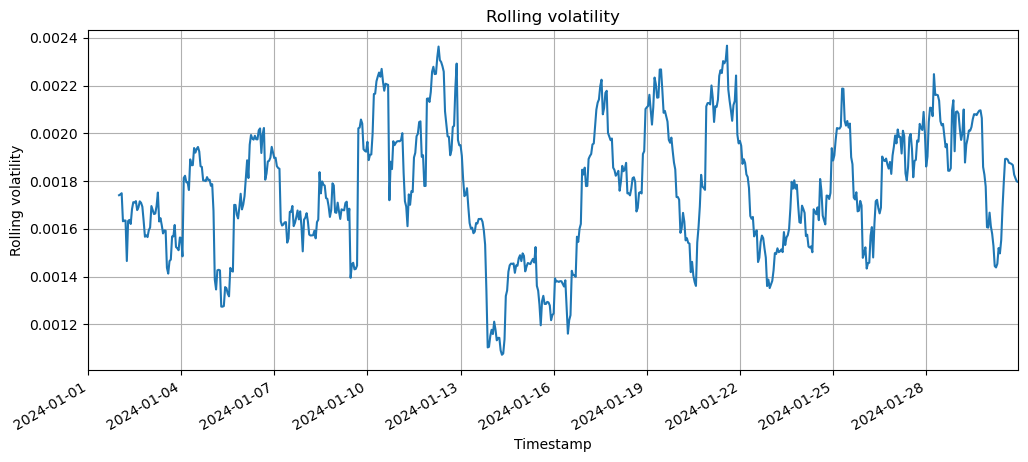

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["rolling_volatility"], linewidth=1.5)

ax.set_title("Rolling volatility")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Rolling volatility")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

ax.set_xlim(df.index.min(), df.index.max())

fig.autofmt_xdate()
plt.show()


## Initial observations

The dataset is sorted by timestamp and indexed as a time series.  
The return column measures percentage price changes between consecutive observations.  
Rolling volatility is calculated as the rolling standard deviation of returns.


## Momentum signal

A simple momentum signal is based on recent returns.  
If the rolling return is positive, the signal is long. If it is negative, the signal is short.


In [40]:
signal_window = 12

df["momentum_signal"] = momentum_signal(df["return"], window=signal_window)

df[["return", "momentum_signal"]].tail()


,return,momentum_signal
timestamp,,
2024-01-30 19:00:00,0.002136,1
2024-01-30 20:00:00,0.000356,1
2024-01-30 21:00:00,0.000421,1
2024-01-30 22:00:00,-0.000505,1
2024-01-30 23:00:00,0.000047,1


## Backtest setup

The signal is shifted by one period before calculating strategy returns.  
This avoids using information from the current bar to trade the same bar.


In [41]:
df["position"] = df["momentum_signal"].shift(1)

df[["momentum_signal", "position"]].tail()


,momentum_signal,position
timestamp,,
2024-01-30 19:00:00,1,-1.0
2024-01-30 20:00:00,1,1.0
2024-01-30 21:00:00,1,1.0
2024-01-30 22:00:00,1,1.0
2024-01-30 23:00:00,1,1.0


## Strategy returns

Strategy returns are calculated by multiplying the shifted position by the market return.


In [42]:
df["strategy_return"] = df["position"] * df["return"]
df["equity_curve"] = (1 + df["strategy_return"].fillna(0)).cumprod()

df[["return", "position", "strategy_return", "equity_curve"]].tail()


,return,position,strategy_return,equity_curve
timestamp,,,,
2024-01-30 19:00:00,0.002136,-1.0,-0.002136,1.047951
2024-01-30 20:00:00,0.000356,1.0,0.000356,1.048324
2024-01-30 21:00:00,0.000421,1.0,0.000421,1.048765
2024-01-30 22:00:00,-0.000505,1.0,-0.000505,1.048236
2024-01-30 23:00:00,0.000047,1.0,0.000047,1.048285


## Backtest metrics

The metrics summarize the simplified momentum backtest.


In [43]:
metrics = pd.DataFrame(
    [
        {
            "strategy": "momentum",
            "cumulative_return": df["equity_curve"].iloc[-1] - 1,
            "max_drawdown": calculate_max_drawdown(df["equity_curve"]),
            "win_rate": calculate_win_rate(df["strategy_return"]),
            "sharpe_like": calculate_sharpe_like(
                df["strategy_return"],
                periods_per_year=24 * 365,
            ),
        }
    ]
)

metrics

,strategy,cumulative_return,max_drawdown,win_rate,sharpe_like
0,momentum,0.048285,-0.028331,0.493741,3.550508


The Sharpe-like value is annualized for illustration only. Because the dataset is synthetic and short, it should not be compared with a professional Sharpe ratio or used as evidence of real strategy quality.

## Equity curve


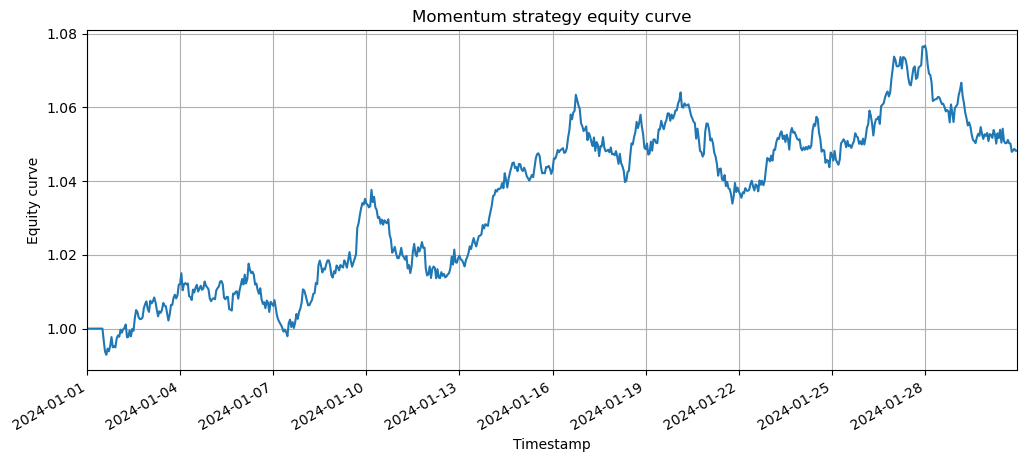

In [44]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["equity_curve"], linewidth=1.5)

ax.set_title("Momentum strategy equity curve")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Equity curve")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

ax.set_xlim(df.index.min(), df.index.max())

fig.autofmt_xdate()
plt.show()


## Drawdown


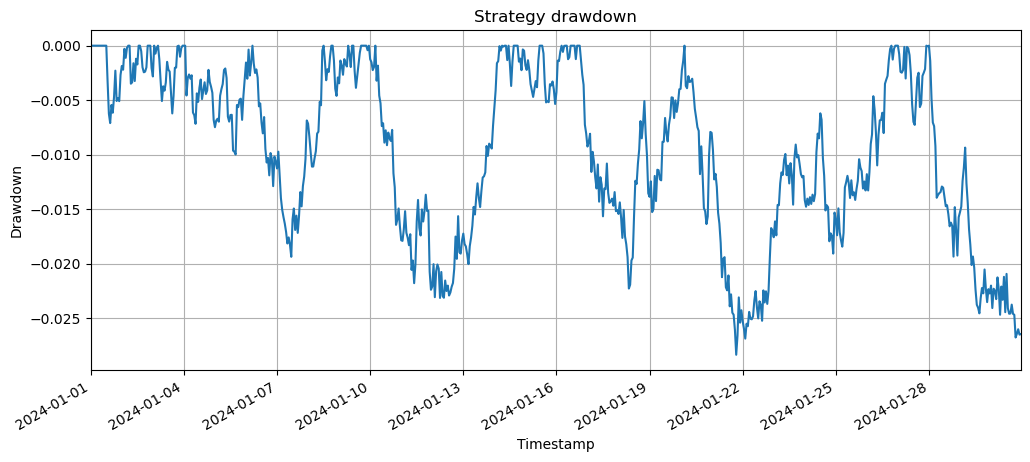

In [45]:
running_max = df["equity_curve"].cummax()
df["drawdown"] = df["equity_curve"] / running_max - 1

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["drawdown"], linewidth=1.5)

ax.set_title("Strategy drawdown")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Drawdown")
ax.grid(True)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

ax.set_xlim(df.index.min(), df.index.max())

fig.autofmt_xdate()
plt.show()


## Position


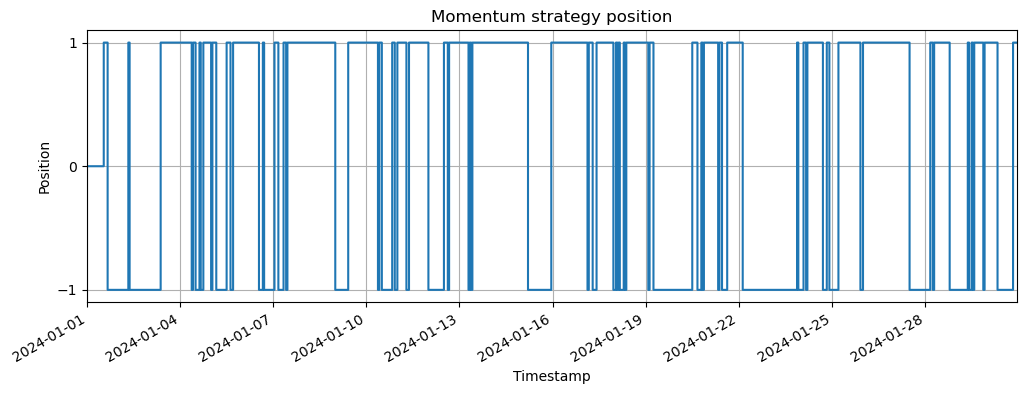

In [46]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.step(df.index, df["position"], where="post")

ax.set_title("Momentum strategy position")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Position")
ax.set_yticks([-1, 0, 1])
ax.grid(True)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

ax.set_xlim(df.index.min(), df.index.max())

fig.autofmt_xdate()
plt.show()


The position chart shows how the shifted momentum signal changes exposure over time. The strategy switches between long and short positions, with some flat exposure at the beginning caused by the rolling window and signal shift.

## Interpretation

On this smoother synthetic sample, the momentum strategy produces a positive cumulative return.

The result should be interpreted carefully. The sample has an upward trend, so the strategy benefits from directional market movement and should not be treated as evidence of a generally profitable trading rule.

The backtest is intentionally simplified. It does not include transaction costs, slippage, liquidity constraints, or out-of-sample validation.